In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna
from sklearn.feature_selection import VarianceThreshold,RFE, mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score, make_scorer, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

In [8]:
fold_1_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_5_val.csv')

In [9]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [10]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [11]:
# Scale using training fold only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [21]:
# Train the model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predict using validation set
y_pred = log_reg.predict(X_val_scaled)

In [23]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("\n Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    print("Accuracy:", accuracy_score(y_true, y_pred))

    metrics = {}

    if y_proba is not None:
        # AUC-PR (Precision-Recall AUC)
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        # ROC AUC (optional)
        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC: {roc_auc:.4f}")

        if plot_pr_curve:
            precision, recall, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



 Classification Report:
              precision    recall  f1-score   support

           0     0.9901    0.6776    0.8046    178711
           1     0.0123    0.3724    0.0237      1920

    accuracy                         0.6744    180631
   macro avg     0.5012    0.5250    0.4142    180631
weighted avg     0.9798    0.6744    0.7963    180631

Confusion Matrix:
[[121097  57614]
 [  1205    715]]
Accuracy: 0.6743692943071787
AUC-PR (Average Precision): 0.0118
ROC AUC: 0.5360


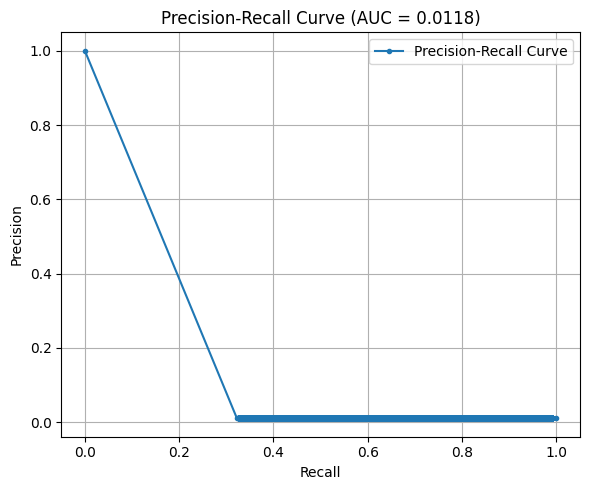

{'auc_pr': 0.011819390565418898, 'roc_auc': 0.5359929914195731}

In [24]:
y_proba = log_reg.predict_proba(X_val)[:, 1]
y_pred = log_reg.predict(X_val)

evaluate_model(y_val, y_pred, y_proba=y_proba)

Logistic Regression serves as our baseline model. While it achieves 67.4% accuracy, it struggles with class imbalance. It only detects ~37% of fraudulent cases and suffers from poor precision (1.23%), resulting in over 57,000 false positives. Its AUC-PR of 0.0118 confirms its inability to rank fraud instances effectively. These results highlight the limitations of linear classifiers in fraud detection and justify the need for more expressive, nonlinear models such as tree-based ensembles.